## 1) LOADING DATASET AND LIBRARIES 

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore") # to ignore warnings of version updates and some features removal in next versions 

from IPython.display import display # print prints text format dataframes so we use display for better view

df = pd.read_csv('IPL-2022-Dataset.csv') # File is in samefolder as this notebook so just the name of file is written as path

## 2) DATAFRAME INFORMATION AND BASIC UNDERSTANDING


### CHECKED GLOBAL STANDARD DATATYPE OF EVERY COLUMN IN DATAFRAME
                                     

In [19]:
display(df.head())
display(df.info())

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

None


### CHECKED THE SIZE OF ROWS AND COLUMNS OF DATAFRAME
                                   

In [20]:
# method vs attribute --> method is function to call , arr.max() / arr.mean()
                     #--> attribute is a fixed attribute of dataset , we dont need brackets at the end of df.shape or arr.size
display(df.shape)
shape = df.shape # tuple or row,column

print(f"Rows : {shape[0]} || Columns : {shape[1]}")



(74, 20)

Rows : 74 || Columns : 20



                                    
### CHECKED NULL VALUES IN EVERY COLUMN OF DATAFRAME
                                     

In [21]:
display(df.isnull().sum())

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

## 3) BASIC ANALYSIS QUESTIONS 

#
### TOTAL NUMBER OF WINS FOR EVERY TEAM 
#                        

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

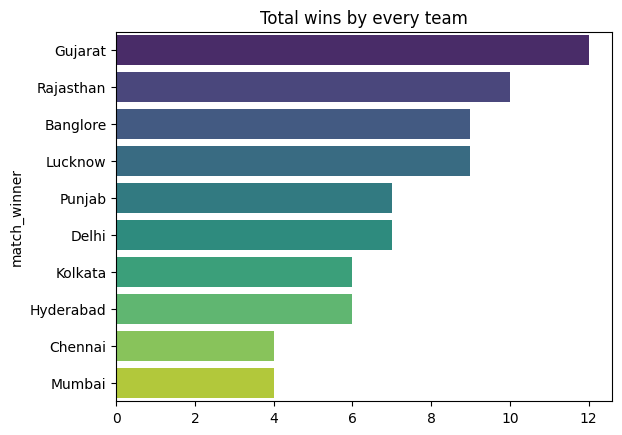

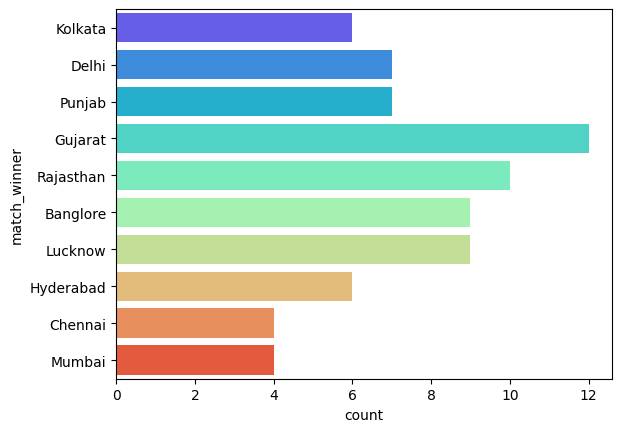

In [129]:
df.head()

#-----------------M1------------------#
match_wins_series = df['match_winner'].value_counts() # df[''].value_counts gives the unique value counts for every unique team in that column 
display(match_wins_series)
# here series ---> is a dictionary with index as match winner and values as counts of it ..

fig = sns.barplot(x = match_wins_series.values , y = match_wins_series.index , palette = 'viridis' , fill=True)
plt.title('Total wins by every team')
plt.savefig('visualization-images/total_wins_per_team_bar_plot.png',bbox_inches = 'tight')
plt.show()

# By count plot , 
sns.countplot( y = 'match_winner' , data = df , palette = 'rainbow' , fill= True)
plt.show()

In [44]:
#----------------M2--------------------#
match_wins = df.groupby(by='match_winner')
display(match_wins.size().sort_values(ascending=False))
display(type(match_wins.size())) 

# remember group by gives us the address of series object never the dataframe 

match_winner
Gujarat      12
Rajasthan    10
Lucknow       9
Banglore      9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
dtype: int64

pandas.core.series.Series

#
### TOSS DECISION TREND 
#

In [54]:
df.head(5)
# field or bat are two options here

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


toss_decision
Field    59
Bat      15
Name: count, dtype: int64

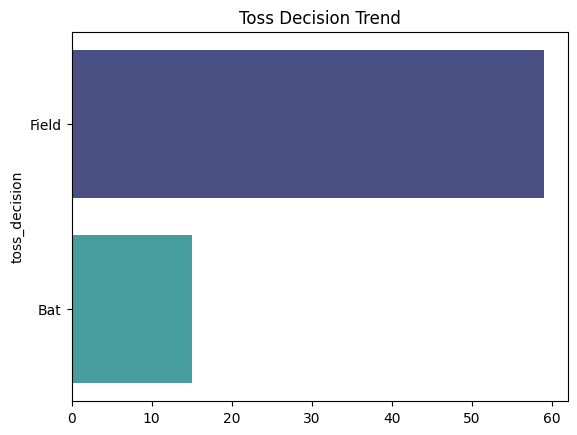




[59 15]


Choosing Field Percentage : 79.73


Choosing  Bat  Percentage : 20.27


In [116]:
toss_trend  = df['toss_decision'].value_counts()
display(toss_trend)

fig  = sns.barplot(x = toss_trend.values , y = toss_trend.index , palette = 'mako')
plt.title('Toss Decision Trend')
plt.savefig('visualization-images/toss_decision_trend_bar_plot.png',bbox_inches = 'tight')
plt.show()

print(f"\n\n\n{toss_trend.values}")
print(f"\n\nChoosing Field Percentage : {(toss_trend.values[0]/df.shape[0])*100 :.2f}")
print(f"\n\nChoosing  Bat  Percentage : {(toss_trend.values[1]/df.shape[0])*100:.2f}")

#
### TOSS WINNER VS MATCH WINNER PERCENTAGE 
#

In [108]:
df.head()
toss_win_vs_match_winner_bool = df['toss_winner'] == df['match_winner']
display(toss_win_vs_match_winner_bool)

df_required_indexes = df[toss_win_vs_match_winner_bool]
display(df_required_indexes.head(5))

print(f" \n\n\nTotal Teams with toss win with match min : {df_required_indexes.shape[0]}")

print(f"\n\nPercentage wins after winning toss          :  {(df_required_indexes.shape[0]/df.shape[0])*100:.2f}")

0      True
1      True
2      True
3      True
4     False
      ...  
69    False
70     True
71    False
72     True
73    False
Length: 74, dtype: bool

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
5,6,"March 30,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Kolkata,Group,Banglore,Field,128,10,132,7,Banglore,Wickets,3,Wanindu Hasaranga,Sherfane Rutherford,28,Wanindu Hasaranga,4--20


 


Total Teams with toss win with match min : 36


Percentage wins after winning toss          :  48.65


False    38
True     36
Name: count, dtype: int64

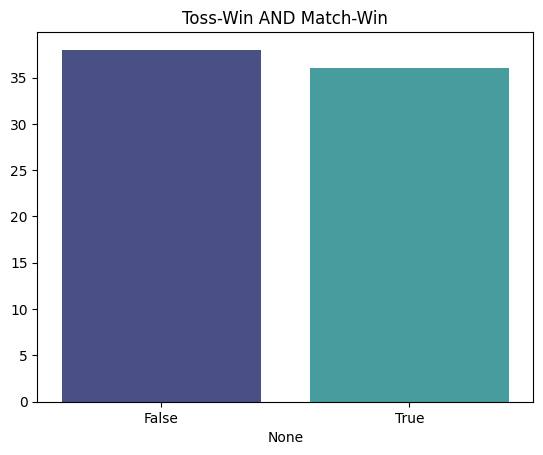

In [105]:
toss_win_vs_match_win_series = toss_win_vs_match_winner_bool.value_counts()
display(toss_win_vs_match_win_series)
sns.barplot(x = toss_win_vs_match_win_series.index , y = toss_win_vs_match_win_series.values , palette = 'mako')
plt.title('Toss-Win AND Match-Win')
plt.savefig('visualization-images/toss_win_and_match_win_bar_plot.png',bbox_inches = 'tight')
plt.show()


#
### HOW DO TEAMS WIN ( RUNS VS WICKETS )
#

In [120]:
df.head()
# we have won by column with won by runs or wickets ..

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


won_by
Wickets    37
Runs       37
Name: count, dtype: int64

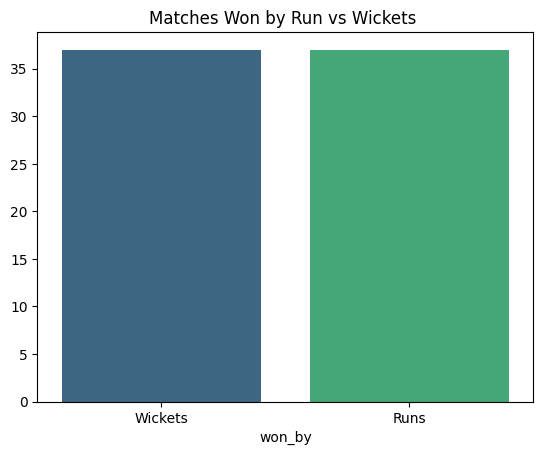

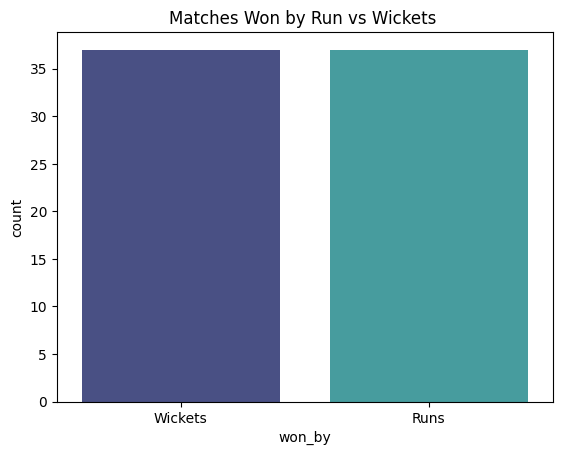

In [158]:
Win_By_Counts = df['won_by'].value_counts()
display(Win_By_Counts)

sns.barplot(x = Win_By_Counts.index , y = Win_By_Counts.values , palette = 'viridis')
plt.title('Matches Won by Run vs Wickets ')
plt.show()

# M2 DIRECT COUNT PLOT ON COLUMN OF WON BY ..
sns.countplot( x = 'won_by' , data =df , palette = 'mako')
plt.title('Matches Won by Run vs Wickets ')
plt.savefig('visualization-images/matches_won_by_runs_vs_wickets_count_plot.png',bbox_inches = 'tight')
plt.show()

#
## 4) KEY PLAYER PERFORMANCES

#
### MOST  PLAYER OF THE MATCH (POTM) AWARDS 
#

In [142]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [166]:
top_potm = df['player_of_the_match'].value_counts(ascending = False)
display(top_potm.head(25))

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
K L Rahul            2
Yuzvendra Chahal     2
David Miller         2
Jasprit Bumrah       2
Umran Malik          2
Evin Lewis           1
Abhishek Sharma      1
Pat Cummins          1
Liam Livingstone     1
Lockie Ferguson      1
Shivam Dube          1
Sanju Samson         1
Odean Smith          1
Mohammed Shami       1
Mayank Agarwal       1
Name: count, dtype: int64

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

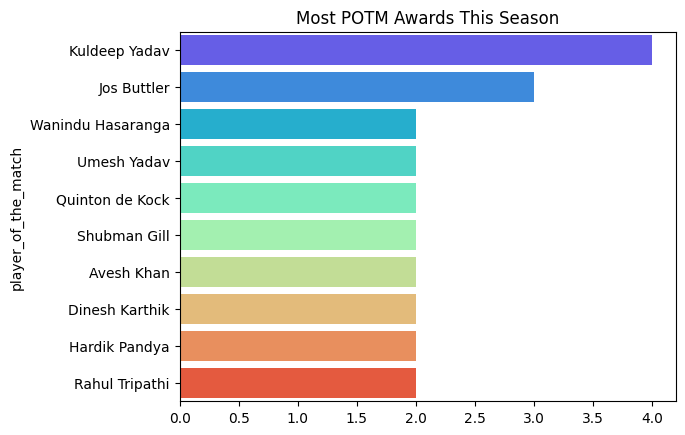

In [167]:
display(top_potm.head(10))

top_10_potm = top_potm.head(10)
sns.barplot( x = top_10_potm.values , y = top_10_potm.index , palette = 'rainbow')
plt.title('Most POTM Awards This Season')
plt.savefig('visualization-images/top_10_potm_awards_season_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
## MOST TOP SCORE RUNS IN ALL MATHCES
#

In [169]:
df.head()
# freq find of every top_scores --> value_counts function on that column 

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [ ]:
top_score_freq = df['top_scorer'].